#### First imports

In [69]:
import pandas as pd
import pyham
from tqdm import tqdm
import itertools
import ete3
import sys
sys.path.append('/work/FAC/FBM/DBC/cdessim2/default/sprietob/FastOMA')
from FastOMA.zoo.hog import extract_hog_info

import numpy as np

import glob
from Bio import SeqIO

In [2]:
!pwd

/work/FAC/FBM/DBC/cdessim2/default/sprietob/tomatoes/phylostratigraphy


### Choose one dataset &rarr; run the variable input for either TE-filtered or TE-unfiltered

#### TE-filtered tree

In [3]:
## Fastoma Files
path = 'fastoma_round2_tree_c/result'
splicePath = path+'/input/splice/'
proteomePath= path+'/input/proteome/'
orthoxmlFile = path+'/FastOMA_HOGs_relabel.orthoxml'

# Results file
resPath = 'tree_c/'

# Tree file
treeFile = 'labelled_trees/tree_c.nwk'


### other files
taxaFile = '/data/'+'names2features.tsv'

### General outputs

hog_infoFile_root = resPath+'hogs_info_root.tsv'
hog_infoFile_all = resPath+'hogs_info_all.tsv'

misplaceFile = f'{resPath}hogs_fail_misplace.tsv'

main_nodes = ['C.01', 'C.02', 'C.03', 'C.04', 'C.05', 'C.08', 'C.09', 'C.10', 'SLL_SLC_SP_DWR', 'C.11', 'C.12', 'C.48', 'C.47', 'C.46', 'C.45', 'C.13', 'C.14', 
              'SLL_SLC_SP', 'SP', 'C.44', 'C.37', 'C.38', 'C.40', 'C.39', 'C.41', 'C.42', 'C.43', 'SLL_SLC', 'SLC', 'C.32', 'C.33', 'C.34', 'C.35', 'C.36', 'SLL', 'C.15', 'C.16', 'C.17', 'C.18', 'C.19', 'C.20', 'C.21', 'C.22', 'C.23', 'C.24', 'C.25', 'C.26', 'C.27', 'C.28', 'C.29', 'C.30', 'C.31']

label_colors=pd.read_csv('tree_c/names2features_tree_C2_bootstrap_grouping.csv')

#### TE-unfiltered tree

In [ ]:
## Fastoma Files
path = 'fastoma_round2_tree_a/result'
splicePath = path+'/input/splice/'
proteomePath= path+'/input/proteome/'
orthoxmlFile = path+'/FastOMA_HOGs_relabel.orthoxml'

# Results file
resPath = 'tree_a/'

# Tree file
treeFile = 'labelled_trees/tree_a.nwk'


### other files
taxaFile = '/data/'+'names2features.tsv'

### General outputs

hog_infoFile_root = resPath+'hogs_info_root.tsv'
hog_infoFile_all = resPath+'hogs_info_all.tsv'

misplaceFile = f'{resPath}hogs_fail_misplace.tsv'

main_nodes=['A.01','A.04','A.05','A.07','A.09','A.12','A.14','A.19','SLL_SLC_SP_DWR','A.20','A.22', 'A.21', 'A_.56', 'A_.57', 'A.58','A.23','A.24',
            'SLL_SLC_SP', 'A.54', 'A.55','A.53','A.52', 'A.25','A.26','A.27','A.28','A.29','SLL_SLC','SLC','A.47','A.48', 'A.49','A.50', 'A.51',  
            'SLL', 'A.30','A.31','A.32', 'A.33','A.34', 'A.35', 'A.36',  'A.37', 'A.38', 'A.39', 'A.40','A.41', 'A.42', 'A.43', 'A.44', 'A.45', 'A.46']

label_colors=pd.read_csv('tree_a/names2features_tree_a2_bootstrap_grouping_NewNames.csv')

## Create ham

In [4]:
### Loading HOGs:
ham_analysis = pyham.Ham(treeFile, orthoxmlFile, use_internal_name=True)

## HOGs quality

#### Functions to calculate CS, hog stats

In [5]:
#########################################
#### Completeness score for rootHOGs ####
#########################################

def completeness_score_rootHOGs(ham_analysis):
    hog2cs = {}
    for (hog_id, hog) in tqdm(ham_analysis.top_level_hogs.items()):
        hog_info = hog.get_all_descendant_genes_clustered_by_species()
        n_sp_in_hog = len(hog_info.keys())
        n_genes_in_hog = sum(1 for _ in itertools.chain.from_iterable(hog_info.values()))
        n_sp_below_root_level = len(hog.genome.taxon.get_leaf_names())
        q = n_sp_in_hog / n_sp_below_root_level    ##This is the completeness_score
        hog2cs[str(hog_id)] = q
    return hog2cs

def get_CS_rootHOGs(neworthoxmlFile, ham_analysis):
    genome_coverage_stats = extract_hog_info.SpeciesAnalyser()
    with open(neworthoxmlFile, 'rt') as xml:
        hog_df = pd.DataFrame.from_records(extract_hog_info.parse_orthoxml(xml, genome_coverage_stats))
    hog_df = hog_df[hog_df.is_roothog].copy() ### keep only root hogs
    print(f"Total number of root HOGs: {hog_df.shape[0]}")
    hogs2cs = completeness_score_rootHOGs(ham_analysis)
    hog_df['CompletenessScore'] = hog_df['id'].map(hogs2cs)
    return hog_df, genome_coverage_stats

#########################################################
#### Completeness score for all subHOGs and rootHOGs ####
#########################################################

def completeness_score_subHOGs(hog,nsp):
    x = hog.get_all_descendant_genes_clustered_by_species()
    n_sp_in_hog = len(x.keys())
    n_genes_in_hog = sum(1 for _ in itertools.chain.from_iterable(x.values()))
    n_sp_below_root_level = len(hog.genome.taxon.get_leaf_names()) ## this no because some hogs can be in other nodes
    q = n_sp_in_hog / nsp    ##This is the completeness_score
    return q

###################
#### hog stats ####
###################

def get_genes_spliceFiles(splicepath, proteomepath):
    files = glob.glob(splicepath+'*')
    proteomes= glob.glob(proteomepath+'*')
    table = {}
    sp_seen=[]
    for f in files:
        sp = f.split('/')[-1].split('.')[0]
        table[sp] = 0
        for line in open(f):
            table[sp] +=1
        sp_seen.append(sp)
    for f in proteomes:
        sp = f.split('/')[-1].split('.')[0]
        if sp not in sp_seen:
            count=sum(1 for _ in SeqIO.parse(f, "fasta"))
            table[sp]=count
        elif sp in sp_seen:
            continue
    return table

def genome_stat(genomes, ham_analysis):
    genomes_hogs = {}
    for (hog_id, hog) in tqdm(ham_analysis.top_level_hogs.items()):
        hog_info = hog.get_all_descendant_genes_clustered_by_species()
        for sp,genes in hog_info.items():
            sp = str(sp)
            if sp not in genomes_hogs:
                genomes_hogs[sp] = 0
            genomes_hogs[sp] += len(genes)
    rows = []
    for sp in genomes:
        genes = genomes[sp] ## total number of genes
        ghogs = genomes_hogs[sp]
        data = (sp, ghogs, genes-ghogs)
        rows.append(data)
    df = pd.DataFrame(rows, columns=["species", "in_HOG", "not_in_HOG"])
    return df

def get_colors_sp_idx(xticks):
    species2mnemo = loadTaxa_reverse(taxaFile)
    main_sp = ['Solanum lycopersicum','Solanum lycopersicum var. cerasiforme','Solanum pimpinellifolium']
    main_sp_col = {'Solanum lycopersicum':'#C7253E','Solanum lycopersicum var. cerasiforme':'#FF9F9F','Solanum pimpinellifolium':'#3AB0FF'}
    sp_dict = {x:species2mnemo[x] for x in main_sp}
    colors_sp = {item:main_sp_col[x] for x in main_sp for item in sp_dict[x]}
    colors = []
    for xtick in xticks:
        taxa = xtick.get_text()
        if taxa in colors_sp:
            col = colors_sp[taxa]
        else:
            col = '#262626ff'
        colors.append(col)
    return colors

#### Get rootHOGs stats file (hog_infoFile_root / hogs_info_root):


In [6]:
hog_df, genome_coverage_stats = get_CS_rootHOGs(orthoxmlFile, ham_analysis) ## root hogs
print(hog_df.head())
hog_df.to_csv(hog_infoFile_root, sep='\t', index=False)

Total number of root HOGs: 51074


100%|██████████| 51074/51074 [00:04<00:00, 12042.49it/s]


                 id level  CompletenessScore  nr_members  is_roothog
62    HOG:0000001_1  C.01           1.000000          66        True
127   HOG:0000002_1  C.01           1.000000          75        True
242   HOG:0000003_1  C.01           0.984375         126        True
292   HOG:0000004_1  C.01           0.781250          54        True
295  HOG:0000005_48  C.28           1.000000           4        True


#### Get (all) HOGs stats file (hog_infoFile_all/ hogs_info_all.tsv)

In [7]:
### Get stats for all hogs:
rdf = pd.read_csv(hog_infoFile_root, sep='\t')
root_hogs = set([f"{a}-{b}" for a, b in zip(rdf['id'], rdf['level'])])
print('Number of root hogs:', rdf.shape[0])
i = 0

with open(hog_infoFile_all, 'w') as fout:
    print('\t'.join(['id','level','CompletenessScore','nr_members','is_roothog']), file=fout)
    for ag in tqdm(ham_analysis.taxonomy.internal_nodes):
        node = ag.name
        genome = ham_analysis.get_ancestral_genome_by_name(node)
        i += len(genome.genes)
        nspecies = len(set(genome.taxon.get_leaf_names()))
        for hog in genome.genes:
            cs = completeness_score_subHOGs(hog, nspecies) ## from orthoxml: hog.scores['CompletenessScore'], but some hogs (ghogs) do not have
            ngenes = len(hog.get_all_descendant_genes())
            root = False
            if f'{hog.hog_id}-{node}' in root_hogs:
                root = True
            dades = [str(x) for x in [hog.hog_id, node, cs, ngenes, root]]
            print('\t'.join(dades), file=fout)
print(f'Number of all hogs in internal branches: {i}')

Number of root hogs: 51074


100%|██████████| 63/63 [01:08<00:00,  1.08s/it]

Number of all hogs in internal branches: 2001468


#### Get misplaced HOGs

In [8]:
hog_df = pd.read_csv(hog_infoFile_root, sep='\t')
print(f'Number of root hogs: {hog_df.shape[0]}')

Number of root hogs: 51074


In [22]:
tree = ete3.Tree(treeFile, format=1)
i = 0
misplacedhogs=[]
with open(misplaceFile,'w') as fout:
    print('hog_id','node_orthoxml','node_real', sep='\t', file=fout)
    for _,row in hog_df.iterrows():
        hog_id, level = row.id, row.level
        hog = ham_analysis.get_hog_by_id(hog_id)
        genes = hog.get_all_descendant_genes_clustered_by_species()
        species = [str(x) for x in genes.keys()]
        if len(species) == 1:
            name = species[0]
        else:
            ag = tree.get_common_ancestor(species)
            name = ag.name
            #print(ag.name)
        clean_name = name.strip("'\"")
        if level != clean_name:
            #print(f"Level: {level}, Name: {clean_name}")
            i +=1
            print(hog_id, level, clean_name, sep='\t', file=fout)
            misplacedhogs.append(hog_id)
print(f'Number of misplaced hogs: {i}, {i*100/hog_df.shape[0]}')

Number of misplaced hogs: 809, 1.5839761914085444


#### HOG quality metrics and filtering

In [12]:
from dendropy import Tree
from collections import Counter

##### Functions

In [14]:
def get_measures(ham, terminal_branches, internal_branches):
    hog_qual = []
    for (hog_id, hog) in tqdm(ham.top_level_hogs.items()):
        x = hog.get_all_descendant_genes_clustered_by_species()
        n_sp_in_hog = len(x.keys())
        n_genes_in_hog = sum(1 for _ in itertools.chain.from_iterable(x.values()))
        n_sp_below_root_level = len(hog.genome.taxon.get_leaf_names())
        q = n_sp_in_hog / n_sp_below_root_level
        hog_qual.append((hog_id, q, n_genes_in_hog))

    df = pd.DataFrame(hog_qual, columns=['hog_id', 'completeness_score', 'n_members'])

    # count implied losses
    implied_losses = Counter()
    duplications_per_hog = Counter()
    stats = []
    for btype, b in tqdm(list(zip(itertools.repeat('terminal'), terminal_branches)) +
                         list(zip(itertools.repeat('internal'), internal_branches))):
        if b[0]==None:
            continue
        tail_genome = ham.get_ancestral_genome_by_name(b[0])
        try:
            head_genome = ham.get_ancestral_genome_by_name(b[1].replace(" ","_"))
        except:
            head_genome = ham.get_extant_genome_by_name(b[1].replace(" ","_"))

        vmap = ham.compare_genomes_vertically(head_genome, tail_genome)
        for g in vmap.get_lost():
            fam_id = g.get_top_level_hog().hog_id
            implied_losses[fam_id] += 1

        for g in vmap.get_duplicated().keys():
            fam_id = g.get_top_level_hog().hog_id
            duplications_per_hog[fam_id] += 1

        # also want to gather the statistics about the size of each of the sets
        x = {'tail_node': b[0],
             'head_node': b[1],
             'retained_head': len(vmap.get_retained().values()),
             'retained_tail': len(vmap.get_retained().keys()),
             'gained': len(vmap.get_gained()),
             'duplicated_head': len(list(itertools.chain.from_iterable(vmap.get_duplicated().values()))),
             'duplicated_tail': len(vmap.get_duplicated().keys()),
             'lost': len(vmap.get_lost()),
             'tail_genome_size': len(tail_genome.genes),
             'head_genome_size': len(head_genome.genes),
             'branch_type': btype}
        stats.append(x)

    branch_stats = pd.DataFrame(stats)

    df['implied_losses'] = df['hog_id'].apply(lambda x: implied_losses[x])
    df['norm_losses'] = (df['implied_losses'] / df['n_members'])
    df['duplications'] = df['hog_id'].apply(lambda x: duplications_per_hog[x])
        
    return df



def get_level(hogid,ham):
    '''Add taxonomic level'''
    hog = ham.get_hog_by_id(hogid)
    level = hog.get_top_level_hog().genome.name
    return level

##### Compute

In [15]:
t = Tree.get(path=treeFile, schema='newick')
n = t.seed_node
terminal_branches = []
internal_branches = []
for n1 in n.level_order_iter():
    if n1.is_leaf():
        terminal_branches.append((n1.parent_node.label, n1.taxon.label))
    else:
        if n1.parent_node is not None:
            internal_branches.append((n1.parent_node.label, n1.label))

/tmp/60811347/ipykernel_4122782/2137399389.py:5: CriticalDeprecationWarning: Deprecated since DendroPy 4: 'level_order_iter()' will no longer be supported in future releases; use 'levelorder_iter()' instead
  for n1 in n.level_order_iter():


In [16]:
df_measures = get_measures(ham_analysis,terminal_branches, internal_branches)
df_measures['level'] = df_measures.apply(lambda x: get_level(x['hog_id'], ham_analysis), axis=1)

100%|██████████| 126/126 [00:12<00:00, 10.25it/s]


In [17]:
filtered_df = df_measures[(df_measures['implied_losses']<=20) & 
                 (df_measures['norm_losses']<=1) & 
                 (df_measures['completeness_score']>=.3)]
print(len(filtered_df))

hogs_to_keep = filtered_df['hog_id'].tolist()

22064


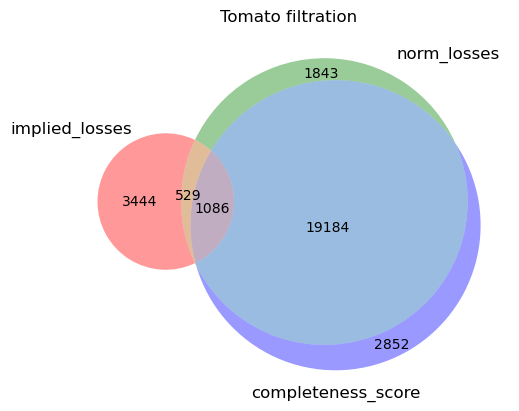

In [19]:
#comparison of filters

from matplotlib import pyplot as plt
from matplotlib_venn import venn3

#hogs to filter out
implied_losses = set(df_measures[df_measures['implied_losses']>20]['hog_id'])
norm_losses = set(df_measures[df_measures['norm_losses']>1]['hog_id'])
completeness_score = set(df_measures[df_measures['completeness_score']<.3]['hog_id'])


def venn3_from_sets(A, B, C, labels=('A','B','C'), title=None):
    # Compute the 7 region sizes in the order expected by venn3:
    only_A   = len(A - B - C)
    only_B   = len(B - A - C)
    A_and_B  = len((A & B) - C)
    only_C   = len(C - A - B)
    A_and_C  = len((A & C) - B)
    B_and_C  = len((B & C) - A)
    A_B_C    = len(A & B & C)

    subsets = (only_A, only_B, A_and_B, only_C, A_and_C, B_and_C, A_B_C)
    venn3(subsets=subsets, set_labels=labels)
    if title:
        plt.title(title)
    plt.show()


A, B, C = implied_losses, norm_losses, completeness_score
venn3_from_sets(A, B, C, labels=('implied_losses','norm_losses','completeness_score'), title='Tomato filtration')

In [20]:
print("Total number of root hogs: {} ".format(len(df_measures)))
print("Total number of root hogs, after filtration: {} ".format(len(hogs_to_keep)))

Total number of root hogs: 51074 
Total number of root hogs, after filtration: 22064 


In [21]:
len(set(hogs_to_keep))

22064

In [23]:
len(misplacedhogs)

809

#### Combine HOGsmisplaced HOGs and quality filter

In [24]:
hogs_to_keep_no_misplaced = [x for x in hogs_to_keep if x not in misplacedhogs]
print("Total number of root hogs, after dup/loss filtration and removal of misplaced hogs: {} ".\
      format(len(hogs_to_keep_no_misplaced)))

Total number of root hogs, after dup/loss filtration and removal of misplaced hogs: 21961 


### Save filtered hogs in file


In [25]:
with open(resPath+"hogs_to_keep.txt", "w") as f:
    for hog in hogs_to_keep:
        f.write(f"{hog}\n")
        
        
with open(resPath+"hogs_to_keep_no_misplaced.txt", "w") as f:
    for hog in hogs_to_keep_no_misplaced:
        f.write(f"{hog}\n")

## Filter orthoxml file (get an orthoxml with only the quality filtered HOGs)

In [27]:
""" Filters (from section above - Quality metrics): 
implied_losses <=20 &
norm_losses <=1 &
completeness_score >=.3
missplaced hogs
"""
hogsFile_flt = f'{resPath}hogs_to_keep_no_misplaced.txt'

In [28]:
# The same info is kept in this file:
df = pd.read_csv(hogsFile_flt, header=None)
hogs_flt = df[0].values
print(f'Number of filtered root hogs: {len(hogs_flt)}')

Number of filtered root hogs: 21961


### Create (or import, if already created) orthoxml of filtered HOGs
(For faster ham loading of the HOG filtered dataset)

In [32]:
from tomato_scripts import extract_hogs

In [ ]:
resPath='tree_c/' # or tree_a
## it's been previously defined, just a double check

In [33]:
outfile = resPath + "FastOMA_HOGs_filtered_relabel.orthoxml"

### **Create** orthoxml:

In [34]:
hog_list = extract_hogs.get_hog_list(hogsFile_flt)

extract_hogs.extract_subset_from_orthoxml(orthoxmlFile, outfile, hog_list)

Number of hogs to keep 21961


## Ham of filtered orthoxml

In [35]:
ham_analysis_filtered = pyham.Ham(treeFile, outfile, use_internal_name=True)

In [36]:
hog_infoFile_filtered_root=resPath+'hogs_info_filtered_root.tsv'
orthoxmlFile_filtered=resPath+'FastOMA_HOGs_filtered_relabel.orthoxml'


### Get stats of root hogs (filtered):

hog_df, genome_coverage_stats = get_CS_rootHOGs(orthoxmlFile_filtered, ham_analysis_filtered) ## root hogs
print(hog_df.head())
hog_df.to_csv(hog_infoFile_filtered_root, sep='\t', index=False)

Total number of root HOGs: 21961


100%|██████████| 21961/21961 [00:01<00:00, 13013.35it/s]


                 id level  CompletenessScore  nr_members  is_roothog
62    HOG:0000001_1  C.01           1.000000          66        True
127   HOG:0000002_1  C.01           1.000000          75        True
242   HOG:0000003_1  C.01           0.984375         126        True
292   HOG:0000004_1  C.01           0.781250          54        True
295  HOG:0000005_48  C.28           1.000000           4        True


#### Get quality filtered HOGS stats file (all HOGs) 

In [37]:
hog_infoFile_filtered_all=resPath+'hogs_info_filtered_all.tsv'

### Get stats for all hogs:
rdf = pd.read_csv(hog_infoFile_filtered_root, sep='\t')
root_hogs = set([f"{a}-{b}" for a, b in zip(rdf['id'], rdf['level'])])
print('Number of root hogs:', rdf.shape[0])
i = 0

with open(hog_infoFile_filtered_all, 'w') as fout:
    print('\t'.join(['id','level','CompletenessScore','nr_members','is_roothog']), file=fout)
    for ag in tqdm(ham_analysis_filtered.taxonomy.internal_nodes):
        node = ag.name
        genome = ham_analysis_filtered.get_ancestral_genome_by_name(node)
        i += len(genome.genes)
        nspecies = len(set(genome.taxon.get_leaf_names()))
        for hog in genome.genes:
            cs = completeness_score_subHOGs(hog, nspecies) ## from orthoxml: hog.scores['CompletenessScore'], but some hogs (ghogs) do not have
            ngenes = len(hog.get_all_descendant_genes())
            root = False
            if f'{hog.hog_id}-{node}' in root_hogs:
                root = True
            dades = [str(x) for x in [hog.hog_id, node, cs, ngenes, root]]
            print('\t'.join(dades), file=fout)
print(f'Number of all hogs in internal branches: {i}')

Number of root hogs: 21961


100%|██████████| 63/63 [00:26<00:00,  2.39it/s]

Number of all hogs in internal branches: 785977


## FIGURES 1C, S11, S12

In [38]:
# DF for all hogs data
df = pd.read_csv(hog_infoFile_all, sep='\t')

## DF for all quality filtered hogs data
dff=pd.read_csv(hog_infoFile_filtered_all, sep='\t')
print(df.shape)
print(dff.shape)

# Some formatting
df['node'] = df['level'].str.extract(r'\.(\d+)$')[0].fillna(df['level'])
df['node'] = df['node'].astype(str)
dff['node'] = dff['level'].str.extract(r'\.(\d+)$')[0].fillna(dff['level'])
dff['node'] = dff['node'].astype(str)

dfc = df['level'].value_counts().to_frame(name='all_HOGs')
dffc = dff['level'].value_counts().to_frame(name='all_HOGs')

dfc['root_HOGs'] = df[df.is_roothog].groupby('level')['id'].nunique()
dffc['root_HOGs'] = dff[dff.is_roothog].groupby('level')['id'].nunique()

(2001468, 5)
(785977, 5)


In [39]:
# MAP NODE NAMES
## We have changed the node names for the clarity of the figures, we use a tsv file to map them

mapfile= resPath+'/nodesC2newnames.tsv' ## Adapt to either nodesC2 or nodesA2
mapping_df=pd.read_csv(mapfile, sep=r"\s+", header=None, names=["level", "value"])
mapping_df["level"] = mapping_df["level"].str.replace("'", "", regex=False)
mapping = dict(zip(mapping_df["level"], mapping_df["value"]))

mapped_order = [mapping.get(x) for x in main_nodes]
mapped_order = [x for x in mapped_order if x is not None]

dfc["mapped_level"] = dfc.index.map(mapping)
dffc["mapped_level"] = dffc.index.map(mapping)
dfc.index = dfc.index.map(mapping)
dffc.index = dffc.index.map(mapping)

dfc.drop(columns=['mapped_level'], inplace=True)
dffc.drop(columns=['mapped_level'], inplace=True)

dfc=dfc[dfc.index.isin(mapped_order)]
dfc = dfc.sort_index()
dfc = dfc.reindex(mapped_order)

dffc = dffc[dffc.index.isin(mapped_order)]
dffc = dffc.sort_index()
dffc = dffc.reindex(mapped_order)

dfc_renamed = dfc.add_suffix("_raw")
dffc_renamed = dffc.add_suffix("_filtered")

# Combine both dataframes
result = pd.concat([dfc_renamed, dffc_renamed], axis=1)
# Now one dataframe for all HOGs ...
result_all=result[['all_HOGs_raw','all_HOGs_filtered']]
# ... and one for rootHOGs
result_root=result[['root_HOGs_raw','root_HOGs_filtered']]

In [40]:
label_colors["id"] = label_colors["id"].replace(mapping)
label_colors["name"] = label_colors["name"].replace(mapping)

label_colors["id"] = label_colors["id"].astype(object)
label_colors["name"] = label_colors["name"].astype(object)

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

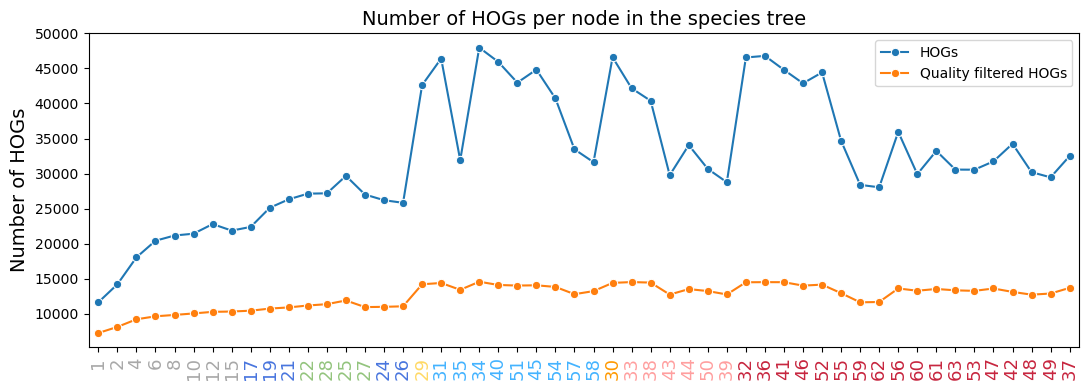

In [42]:
### FIGURE 1C --- with Tree C dataset (orthoxml + tree), which is the TE-filtered tree dataset

fig, ax1 = plt.subplots(figsize=(11, 4))

x_pos = range(len(result_all))  # 0..N positions

# --- Single plot: all HOGs ---
sns.lineplot(x=x_pos, y=result_all['all_HOGs_raw'], marker='o', ax=ax1, label='HOGs')
sns.lineplot(x=x_pos, y=result_all['all_HOGs_filtered'], marker='o', ax=ax1, label='Quality filtered HOGs')

ax1.legend()
ax1.set_title('Number of HOGs per node in the species tree', size=14)
ax1.set_ylabel('Number of HOGs', size=14)

# Margins
ax1.margins(x=0.01)

# --- Apply the SAME xticks as previously on bottom panel ---
ax1.set_xticks(x_pos)
ax1.set_xticklabels(mapped_order, rotation=90, size=13)

# --- Apply colors to x tick labels ---
color_map = dict(zip(label_colors["id"].astype(str), label_colors["color"]))

for tick_label in ax1.get_xticklabels():
    node = tick_label.get_text()
    if node in color_map:
        tick_label.set_color(color_map[node])

plt.tight_layout()
#plt.savefig(resPath + 'HOGs-node-1panel_numbernodes.svg', dpi=600)
plt.show()

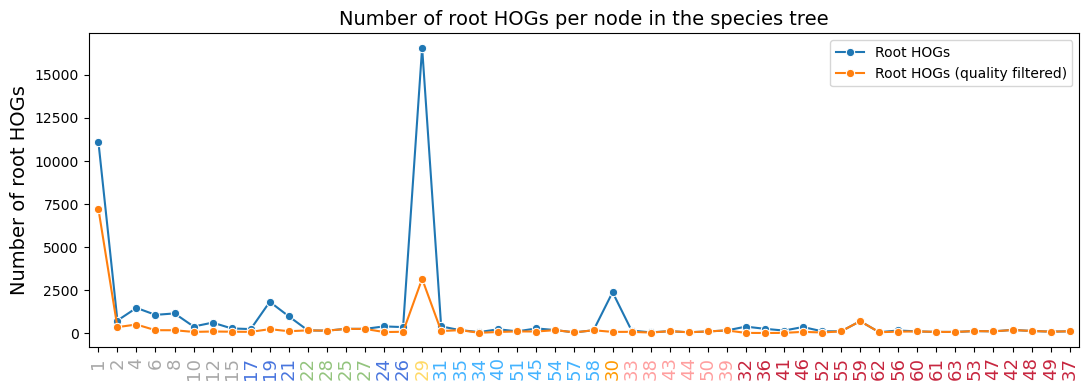

In [43]:
## FIGURE S12 --- with Tree C dataset (orthoxml + tree), which is the TE-filtered tree dataset

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax2 = plt.subplots(figsize=(11, 4))

x_pos = range(len(result_root))  # 0..N positions

# --- Single plot: root HOGs ---
sns.lineplot(x=x_pos, y=result_root['root_HOGs_raw'], marker='o', ax=ax2, label='Root HOGs')
sns.lineplot(x=x_pos, y=result_root['root_HOGs_filtered'], marker='o', ax=ax2, label='Root HOGs (quality filtered)')

ax2.legend()
ax2.set_title('Number of root HOGs per node in the species tree', size=14)
ax2.set_ylabel('Number of root HOGs', size=14)

# Margins
ax2.margins(x=0.01)

# --- Same xticks as before ---
ax2.set_xticks(x_pos)
ax2.set_xticklabels(mapped_order, rotation=90, size=13)

# --- Apply colors to x tick labels ---
color_map = dict(zip(label_colors["id"].astype(str), label_colors["color"]))

for tick_label in ax2.get_xticklabels():
    node = tick_label.get_text()
    if node in color_map:
        tick_label.set_color(color_map[node])

plt.tight_layout()
#plt.savefig(resPath + 'HOGs-node-1panel_rootHOGs.svg', dpi=600)
plt.show()

In [ ]:
## FIGURE S11 --- with Tree A dataset (orthoxml + tree), which is the TE-unfiltered tree dataset

import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
x_pos = range(len(result_all))  # 0..N positions
# --- Top plot: all HOGs ---
ax1 = sns.lineplot(x=x_pos, y=result_all['all_HOGs_raw'], marker='o', ax=axes[0], label= 'All HOGs')
sns.lineplot(x=x_pos, y=result_all['all_HOGs_filtered'], marker='o', ax=axes[0], label= 'All HOGs (quality filtered)')
ax1.legend()
ax1.set_title('Number of HOGs per node in the species tree', size=14)
ax1.set_ylabel('Number of HOGs', size=14)
#ax1.tick_params(axis='y',labelsize=13)

# --- Bottom plot: root HOGs ---
#ax2 = sns.lineplot(data=result_root, marker='o', linewidth=2, markersize=8, ax=axes[1])

ax2 = sns.lineplot(x=x_pos, y=result_root['root_HOGs_raw'], marker='o', ax=axes[1], label='Root HOGs')
sns.lineplot(x=x_pos, y=result_root['root_HOGs_filtered'], marker='o', ax=axes[1], label='Root HOGs (quality filtered)')
ax2.legend()
ax2.set_ylabel('Number of root HOGs', size=14)
ax2.set_xlabel('')
#ax2.tick_params(axis='y',labelsize=12)

ax1.margins(x=0.01)
ax2.margins(x=0.01)

# Shared x ticks
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(mapped_order, rotation=90, size=13)

# Assume dfc.index has the node labels, result_all and result_root have same order
x_values = range(len(dfc.index))

# Apply colors to x tick labels (only need on bottom axis)
color_map = dict(zip(label_colors["id"].astype(str), label_colors["color"]))

for tick_label in axes[1].get_xticklabels():
    node = tick_label.get_text()
    if node in color_map:
        tick_label.set_color(color_map[node])
        
plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
#plt.savefig(resPath + 'HOGs-node-2panels_numbernodes.svg', dpi=600)
plt.show()


## Branch-wise phylostratigraphy analysis

In [44]:
import itertools
def compute_tree_profile_full(ham_data):
        def _add_annot(node, nbr, duplicated_child_count, duplicated_parent_count, arose_by_duplication, duplication_events
                       ,lost, gained, retained, nbr_ev):
            node.add_feature("nbr_genes", nbr)
            node.add_feature("duplicated_child_count", duplicated_child_count)
            node.add_feature("duplicated_parent_count", duplicated_parent_count)
            node.add_feature("arose_by_duplication", arose_by_duplication)
            node.add_feature("duplication_events", duplication_events) 
            node.add_feature("lost", lost)
            node.add_feature("gained", gained)
            node.add_feature("retained", retained)
            node.add_feature("nbr_events", nbr_ev)


        if ham_data.taxonomy.tree_format == 'phyloxml':
            # Rebuild full tree from input data and annotate it with name if required
            treeMap = ham_data.taxonomy._build_tree(ham_data.taxonomy.tree_file, ham_data.taxonomy.tree_format)
            ham_data.taxonomy._generate_internal_node_name(treeMap)
        else:
            treeMap = ham_data.taxonomy.tree.copy(method="newick")

        for node in treeMap.traverse():
            if node.is_root():
                node_genome = ham_data.get_ancestral_genome_by_name(node.name)
                _add_annot(node, len(node_genome.genes),
                   None, None, None, None,
                   None, None, None, None)

            else:
                node_genome_up = ham_data._get_ancestral_genome_by_name(node.up.name)

                if node.is_leaf():
                    node_genome = ham_data._get_extant_genome_by_name(name=node.name)
                    nbr = node_genome.get_number_genes(singleton=True)

                else:
                    node_genome = ham_data._get_ancestral_genome_by_name(node.name)
                    nbr = node_genome.get_number_genes()

                vmap = ham_data.compare_genomes_vertically(node_genome, node_genome_up)
                
                duplicated_child_count = len(set(itertools.chain.from_iterable(vmap.get_duplicated().values())))
                duplicated_parent_count = len(set(vmap.get_duplicated().keys()))
                arose_by_duplication= duplicated_child_count- duplicated_parent_count

                nbr_dup = getattr(vmap.map, "number_duplication", 0)
                nbr_ev = nbr_dup + len(vmap.get_lost()) + len(vmap.get_gained())

                nr_retained=len(vmap.get_retained().keys()) + duplicated_parent_count # The genes already duplicated at parent count as retained
                
                _add_annot(node, nbr, duplicated_child_count,duplicated_parent_count, arose_by_duplication, nbr_dup, len(vmap.get_lost()), 
                           len(vmap.get_gained()), nr_retained, nbr_ev)

        return treeMap

In [45]:
def get_tree_stats(ham, treemap):
    #get stats for each genome

    treemap_df = pd.DataFrame()

    treemap_tmp_df = pd.DataFrame()
    for node in treemap.iter_descendants():
        if node.is_leaf()==True:
            genome_type = 'extant'
            nb_genes = len(ham.get_extant_genome_by_name(node.name).genes)
        else:
            genome_type = 'ancestral'
            nb_genes = len(ham.get_ancestral_genome_by_name(node.name).genes)

        parent = node.get_ancestors()[0].name
        nb_genes_parent = len(ham.get_ancestral_genome_by_name(parent).genes)

        #add nb genes, events counts and parent info
        row = {'taxa': node.name, 'genome_type': genome_type, 'nb_genes': nb_genes, 'nb_events': int(node.nbr_events), 'nb_gained': node.gained, 
               'nb_duplicated': node.arose_by_duplication, 'nb_retained': node.retained,'nb_lost': node.lost, 'nb_duplication_events': node.duplication_events, 'parent': parent, 'nb_genes_parent': nb_genes_parent}
        #Nb_duplicated = nb of genes that arose via duplication instead
        
        treemap_tmp_df = pd.concat([treemap_tmp_df, pd.DataFrame([row])])

    #get % of dup, lost, retained, and gained
    for event in ["duplicated", "retained", "gained"]:
        treemap_tmp_df['%_'+ event] = treemap_tmp_df.apply(lambda x: x['nb_'+ event]/x['nb_genes']*100, axis=1)

    ## % of lost genes is % of parent genes
    treemap_tmp_df['%_lost'] = treemap_tmp_df.apply(lambda x: x['nb_lost']/x['nb_genes_parent']*100, axis=1)



    #polytomy stuff
    treemap_tmp_df['nb_children_for_direct_parent'] = treemap_tmp_df['taxa'].apply(lambda x: \
                                    len(treemap.search_nodes(name=x)[0].get_ancestors()[0].children))

    ## nb children for node itself
    treemap_tmp_df['nb_children'] = treemap_tmp_df.apply(lambda x: \
                                                 len(treemap.search_nodes(name=x['taxa'])[0].children) \
                                                if x['genome_type']=='ancestral' \
                                                else np.nan, axis=1)


    treemap_tmp_df = treemap_tmp_df.reset_index().drop(columns=['index'])
    treemap_tmp_df['dataset'] = 'Tree_C'
    treemap_df = pd.concat([treemap_df, treemap_tmp_df])

    #save treemap file
    #treemap_df.to_csv(fastoma_datasets[dataset]['fastoma_dir'] + 'treemap_df.csv')
    
    return treemap_df

In [46]:
def bar_profile(treemap_df, outname, main_nodes, size, nopoly=False, label_colors=None):
    import pandas as pd
    import matplotlib.pyplot as plt

    colors = [ "#BCE0F9","#E2DE11", "#3CC30B", "#B71818"]
    label_legend = [ "Retained","Duplicated","Gained","Lost"]

    df=treemap_df[['taxa','%_retained','%_duplicated','%_gained','%_lost']]
    df.set_index('taxa', inplace=True)
    if main_nodes != 'leaves':
        df = df.reindex([str(x) for x in main_nodes])

    columns = list(df.columns[:-1])

    for name in columns:
        df[name] = df[name]


    df['%_lost'] *= -1  # make lost negative

    # Plot
    ax = df.plot(kind='bar', stacked=True, color=colors, figsize=size)

    # Handle leaf filtering
    if main_nodes == 'leaves' and nopoly:
        df = df.drop(['NICTA', 'NICBE'], axis=0, errors='ignore')

    # Apply tick label colors from table
    if label_colors is not None:
        # Build mapping
        color_map = dict(zip(label_colors["id"].astype(str),
                             label_colors["color"]))

        for label in ax.get_xticklabels():
            node = label.get_text()

            # optional cleaning if needed
            node_clean = node.replace("_LG", "")

            label.set_color(color_map.get(node_clean, "black"))
    
    ax.legend(label_legend)
    ax.tick_params(labelsize=13)
    plt.ylabel('Proportion of HOGs', size=15)
    plt.savefig(outname, bbox_inches='tight')
    plt.show()

    return df

In [57]:
treemap_df

,taxa,genome_type,nb_genes,nb_events,nb_gained,nb_duplicated,nb_retained,nb_lost,nb_duplication_events,parent,nb_genes_parent,%_duplicated,%_retained,%_gained,%_lost,nb_children_for_direct_parent,nb_children,dataset,taxa_mapped
0,2,ancestral,8105,872,352,520,7233,0,520,C.01,7233,6.415793,89.241209,4.342998,0.000000,2,2.0,Tree_C,2
1,3,ancestral,10225,2992,568,2424,7233,0,2424,C.01,7233,23.706601,70.738386,5.555012,0.000000,2,2.0,Tree_C,3
2,4,ancestral,9190,1209,503,644,8043,62,644,C.02,8105,7.007617,87.519042,5.473341,0.764960,2,2.0,Tree_C,4
3,nan,extant,9609,3216,0,2360,7249,856,2360,C.02,8105,24.560308,75.439692,0.000000,10.561382,2,NaN,Tree_C,nan
4,nan,extant,9650,3097,0,1261,8389,1836,1261,C.56,10225,13.067358,86.932642,0.000000,17.955990,2,NaN,Tree_C,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,63,ancestral,13326,349,72,6,13248,271,6,C.24,13519,0.045025,99.414678,0.540297,2.004586,2,2.0,Tree_C,63
122,nan,extant,11298,367,0,3,11295,364,3,C.21,11659,0.026553,99.973447,0.000000,3.122052,2,NaN,Tree_C,nan
123,nan,extant,11431,300,0,36,11395,264,36,C.21,11659,0.314933,99.685067,0.000000,2.264345,2,NaN,Tree_C,nan
124,nan,extant,12724,632,0,15,12709,617,15,C.25,13326,0.117887,99.882113,0.000000,4.630047,2,NaN,Tree_C,nan


In [58]:
#all_nodes = [x for x in range(1,64)] ## all nodes 
leaf_names = [leaf.name for leaf in tree.iter_leaves()] ## all leaves (64)
all_nodes = list(tree.traverse())
#node_names = [node.name for node in tree.traverse()]
node_names = [n.name.strip("'") for n in tree.traverse() if not n.is_leaf()]
internal_node_names = [n.name for n in tree.traverse() if not n.is_leaf()]
treemap = compute_tree_profile_full(ham_analysis_filtered) ## filterin hogs

treemap_df=get_tree_stats(ham_analysis_filtered, treemap)

#main_nodes=[str(x) for x in main_nodes[1:]]
## when MAPPED
main_nodes=[str(x) for x in mapped_order[1:]]

In [61]:
# MAP to updated node names for figures

treemap_df['taxa'] = (
    treemap_df['taxa']
    .map(mapping)
    .fillna(treemap_df['taxa'])
    .astype(str)
    .str.split('.')
    .str[0]
)

In [ ]:
tree_c_all_nodes=[3,5,2,4,7,6,9,8,11,14,10,16,18,20,23,12,15,17,19,21,22,25,28,27,24,26,29,31,35,34,40,
                  45,51,54,57,58,30,33,39,38,44,50,43,32,37,36,42,48,49,41,47,46,53,52,56,60,61,63,55,59,62]

tree_a_all_nodes=[2,4,3,5,6,7,8,9,10,11,13,14,15,17,19,21,14,16,18,20,23,22,25,28,27,24,26,29,30,31,33,35,37,39,32,34,36,38,41,45,52,44,50,51,
                  40,43,49,59,62,58,48,57,61,42,47,55,56,46,54,53,60,63]

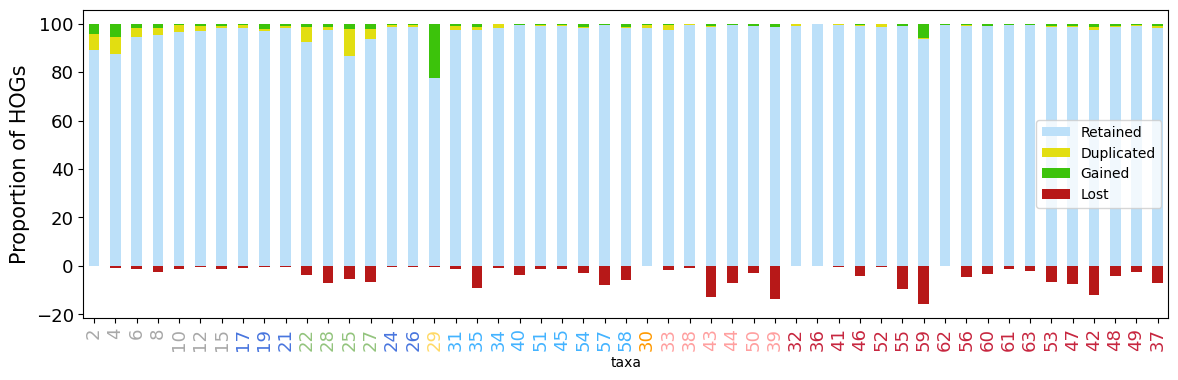

In [63]:
# Choose nodes to plot (main_nodes or tree_x_all_nodes)

# This will create a df with the proportion of HOGs and at the same time, output the corresponding figure to the path specified in the second argument.

df = bar_profile(treemap_df, f'{resPath}figure4B.svg', main_nodes, (14,4), label_colors=label_colors)
# It will be figure S16 A or B (depending on tree/dataset) if using all nodes

## Create HOG metrics table (Table S7) for (HOG-quality) unfiltered FastOMAs

#### Function

In [73]:
def loadTaxa_reverse(inFile):
    species = {}
    for line in open(inFile):
        line = line.strip()
        data = line.split('\t')
        if data[1] not in species:
            species[data[1]] = set()
        species[data[1]].add(data[0])
    return species

#### Create tables

In [65]:
#### !!
taxaFile='data/names2features.tsv'

dataset_configs = [
    {
        "name": "Tree_A",
        "path": 'fastoma_round2_tree_a/',
        "treeFile": 'labelled_trees/tree_a.nwk',
        "resPath": 'tree_a/'
    },
    {
        "name": "Tree_C",
        "path": 'fastoma_round2_tree_c/',
        "treeFile": 'labelled_trees/tree_c.nwk',
        "resPath": 'tree_c/'
    }]

In [75]:
results=[]
for cfg in dataset_configs:

    # Load dataset
    path = cfg["path"]
    resPath = cfg["resPath"]

    orthoxmlFile = path + 'result/FastOMA_HOGs_relabel.orthoxml'
    splicePath = path + 'input/splice/'
    proteomePath = path + 'input/proteome/'
    hog_infoFile_root = resPath + 'hogs_info_root.tsv'
    misplaceFile = resPath + 'hogs_fail_misplace.tsv'
    
    treeFile=cfg["treeFile"]

    taxafile=pd.read_csv(taxaFile, sep='\t')
    
    ham_analysis = pyham.Ham(treeFile, orthoxmlFile, use_internal_name=True)
    tree=ete3.Tree(treeFile, format=1)
    genomes = get_genes_spliceFiles(splicePath, proteomePath)
    hog_summary_df = genome_stat(genomes, ham_analysis) #pd.DataFrame.from_records(genome_coverage_stats.summary())
    df_seq = hog_summary_df
    order = tree.get_leaf_names()
    df_seq = df_seq.sort_values(by=['species'], key=lambda s: s.apply(order.index)).set_index('species')
    species2mnemo = loadTaxa_reverse(taxaFile)
    
    
    main_sp = ['Solanum pimpinellifolium', 'Solanum lycopersicum var. cerasiforme', 'Solanum lycopersicum']
    ## list of tomato genomes
    popu = [item for sublist in [species2mnemo[x] for x in main_sp] for item in sublist]
    
    ## TOMATOES
    df = df_seq.copy()
    df = df[df.index.isin(popu)]
    df = df.reindex(popu)
    df['in_HOG_perc']= df['in_HOG']/ (df['in_HOG']+df['not_in_HOG'])
    df['not_in_HOG_perc']=df['not_in_HOG']/(df['in_HOG']+df['not_in_HOG'])
    df['health_check']=df['in_HOG_perc']+df['not_in_HOG_perc']

    ## OUTGROUPS
    df2=df_seq.copy()
    df2=df2[~df2.index.isin(popu)]
    df2['in_HOG_perc']= df2['in_HOG']/ (df2['in_HOG']+df2['not_in_HOG'])
    df2['not_in_HOG_perc']=df2['not_in_HOG']/(df2['in_HOG']+df2['not_in_HOG'])
    df2['health_check']=df2['in_HOG_perc']+df2['not_in_HOG_perc']

    ## ALL
    df_seq['in_HOG_perc']= df_seq['in_HOG']/ (df_seq['in_HOG']+df_seq['not_in_HOG'])
    df_seq['not_in_HOG_perc']=df_seq['not_in_HOG']/(df_seq['in_HOG']+df_seq['not_in_HOG'])
    df_seq['health_check']=df_seq['in_HOG_perc']+df_seq['not_in_HOG_perc']

    perc_inHOG=df_seq['in_HOG_perc'].mean()
    perc_inHOG_tomatoes=df['in_HOG_perc'].mean()
    perc_inHOG_outgroups=df2['in_HOG_perc'].mean()

    ## HOGS
    rdf = pd.read_csv(hog_infoFile_root, sep='\t')
    avg_roothog_cs = rdf.loc[rdf["is_roothog"] == True, "CompletenessScore"].mean()    # Run calculations
    
    misplaced_df=pd.read_csv(misplaceFile, sep='\t')
    i=0
    misplacedhogs=[]
    for _,row in rdf.iterrows():
        hog_id, level = row.id, row.level
        hog = ham_analysis.get_hog_by_id(hog_id)
        genes = hog.get_all_descendant_genes_clustered_by_species()
        species = [str(x) for x in genes.keys()]
        if len(species) == 1:
            name = species[0]
        else:
            ag = tree.get_common_ancestor(species)
            name = ag.name.strip("'")
        if level != name:
            i +=1
            misplacedhogs.append(hog_id)

    n_misplaced_rthogs=i
    perc_misplaced_rthogs=i*100/rdf.shape[0]
    
    t = Tree.get(path=treeFile, schema='newick')
    n = t.seed_node
    terminal_branches = []
    internal_branches = []
    for n1 in n.level_order_iter():
        if n1.is_leaf():
            terminal_branches.append((n1.parent_node.label, n1.taxon.label))
        else:
            if n1.parent_node is not None:
                internal_branches.append((n1.parent_node.label, n1.label))
    
    df_metrics=get_measures(ham_analysis, terminal_branches, internal_branches)

    df_metrics['level'] = df_metrics.apply(lambda x: get_level(x['hog_id'], ham_analysis), axis=1)

    hogs_more20losses= len(df_metrics[df_metrics['implied_losses']>20])
    hogs_more1normlosses=len(df_metrics[df_metrics['norm_losses']>1])
    hogs_less30cs=len(df_metrics[df_metrics['completeness_score']<0.3])

    results.append({
        "dataset": cfg["name"],
        "avg_percentage_inHOGs": perc_inHOG,
        "tomatoes_avg_percentage_inhogs": perc_inHOG_tomatoes,
        "outgroups_avg_percentage_inhogs": perc_inHOG_outgroups,
        "avg_cs_rthogs": avg_roothog_cs,
        "hogs_under30cs":hogs_less30cs,
        "n_hogs_more20_impl-losses": hogs_more20losses,
        "n_hogs_more1_norm-losses":hogs_more1normlosses,
        "n_misplaced_rthogs": n_misplaced_rthogs,
        "perc_misplaced_rthogs":perc_misplaced_rthogs
    })

100%|██████████| 62268/62268 [00:03<00:00, 18176.00it/s]
/tmp/60811347/ipykernel_4122782/3282515500.py:84: CriticalDeprecationWarning: Deprecated since DendroPy 4: 'level_order_iter()' will no longer be supported in future releases; use 'levelorder_iter()' instead
  for n1 in n.level_order_iter():
100%|██████████| 51074/51074 [00:03<00:00, 16154.92it/s]
/tmp/60811347/ipykernel_4122782/3282515500.py:84: CriticalDeprecationWarning: Deprecated since DendroPy 4: 'level_order_iter()' will no longer be supported in future releases; use 'levelorder_iter()' instead
  for n1 in n.level_order_iter():
100%|██████████| 126/126 [00:08<00:00, 14.21it/s]


### Export results metrics

In [ ]:
summary_df = pd.DataFrame(results)
summary_df.to_csv('HOGs_metrics.csv')

## HOG metrics for (HOG-quality) filtered FastOMAs

In [79]:
taxaFile='data/names2features.tsv'

dataset_configs = [
    {
        "name": "Tree_C_filtered",
        "path": 'fastoma_round2_tree_c/',
        "treeFile": 'labelled_trees/tree_c.nwk',
        "resPath": 'tree_c/'
    },
    {
        "name": "Tree_A_filtered",
        "path": 'fastoma_round2_tree_a/',
        "treeFile": 'tree_a.nwk',
        "resPath": 'tree_a/'
    }        
]

In [80]:
results=[]
for cfg in dataset_configs:

    # Load dataset
    path = cfg["path"]
    resPath = cfg["resPath"]

    orthoxmlFile = resPath + 'FastOMA_HOGs_filtered_relabel.orthoxml'
    splicePath = path + 'input/splice/'
    proteomePath = path + 'input/proteome/'
    hog_infoFile_root = resPath + 'hogs_info_filtered_root.tsv'
    misplaceFile = resPath + 'hogs_fail_misplace.tsv'
    
    treeFile=cfg["treeFile"]

    
    taxafile=pd.read_csv(taxaFile, sep='\t')
    
    ham_analysis = pyham.Ham(treeFile, orthoxmlFile, use_internal_name=True)
    tree=ete3.Tree(treeFile, format=1)
    genomes = get_genes_spliceFiles(splicePath, proteomePath)
    hog_summary_df = genome_stat(genomes, ham_analysis) #pd.DataFrame.from_records(genome_coverage_stats.summary())
    df_seq = hog_summary_df
    order = tree.get_leaf_names()
    df_seq = df_seq.sort_values(by=['species'], key=lambda s: s.apply(order.index)).set_index('species')
    
    
    species2mnemo = loadTaxa_reverse(taxaFile)
    main_sp = ['Solanum pimpinellifolium', 'Solanum lycopersicum var. cerasiforme', 'Solanum lycopersicum']
    ## list of tomato genomes
    popu = [item for sublist in [species2mnemo[x] for x in main_sp] for item in sublist]
    
    ## TOMATOES
    df = df_seq.copy()
    df = df[df.index.isin(popu)]
    df = df.reindex(popu)
    df['in_HOG_perc']= df['in_HOG']/ (df['in_HOG']+df['not_in_HOG'])
    df['not_in_HOG_perc']=df['not_in_HOG']/(df['in_HOG']+df['not_in_HOG'])
    df['health_check']=df['in_HOG_perc']+df['not_in_HOG_perc']

    ## OUTGROUPS
    df2=df_seq.copy()
    df2=df2[~df2.index.isin(popu)]
    df2['in_HOG_perc']= df2['in_HOG']/ (df2['in_HOG']+df2['not_in_HOG'])
    df2['not_in_HOG_perc']=df2['not_in_HOG']/(df2['in_HOG']+df2['not_in_HOG'])
    df2['health_check']=df2['in_HOG_perc']+df2['not_in_HOG_perc']

    ## ALL
    df_seq['in_HOG_perc']= df_seq['in_HOG']/ (df_seq['in_HOG']+df_seq['not_in_HOG'])
    df_seq['not_in_HOG_perc']=df_seq['not_in_HOG']/(df_seq['in_HOG']+df_seq['not_in_HOG'])
    df_seq['health_check']=df_seq['in_HOG_perc']+df_seq['not_in_HOG_perc']

    perc_inHOG=df_seq['in_HOG_perc'].mean()
    perc_inHOG_tomatoes=df['in_HOG_perc'].mean()
    perc_inHOG_outgroups=df2['in_HOG_perc'].mean()

    ## HOGS
    rdf = pd.read_csv(hog_infoFile_root, sep='\t')
    avg_roothog_cs = rdf.loc[rdf["is_roothog"] == True, "CompletenessScore"].mean()    # Run calculations
    
    misplaced_df=pd.read_csv(misplaceFile, sep='\t')
    i=0
    misplacedhogs=[]
    for _,row in rdf.iterrows():
        hog_id, level = row.id, row.level
        hog = ham_analysis.get_hog_by_id(hog_id)
        genes = hog.get_all_descendant_genes_clustered_by_species()
        species = [str(x) for x in genes.keys()]
        if len(species) == 1:
            name = species[0]
        else:
            ag = tree.get_common_ancestor(species)
            name = ag.name.strip("'")
        if level != name:
            i +=1
            misplacedhogs.append(hog_id)

    n_misplaced_rthogs=i
    perc_misplaced_rthogs=i*100/rdf.shape[0]
    
    t = Tree.get(path=treeFile, schema='newick')
    n = t.seed_node
    terminal_branches = []
    internal_branches = []
    for n1 in n.level_order_iter():
        if n1.is_leaf():
            terminal_branches.append((n1.parent_node.label, n1.taxon.label))
        else:
            if n1.parent_node is not None:
                internal_branches.append((n1.parent_node.label, n1.label))
    
    df_metrics=get_measures(ham_analysis, terminal_branches, internal_branches)

    df_metrics['level'] = df_metrics.apply(lambda x: get_level(x['hog_id'], ham_analysis), axis=1)

    hogs_more20losses= len(df_metrics[df_metrics['implied_losses']>20])
    hogs_more1normlosses=len(df_metrics[df_metrics['norm_losses']>1])
    hogs_less30cs=len(df_metrics[df_metrics['completeness_score']<0.3])

    results.append({
        "dataset": cfg["name"],
        "avg_percentage_inHOGs": perc_inHOG,
        "tomatoes_avg_percentage_inhogs": perc_inHOG_tomatoes,
        "outgroups_avg_percentage_inhogs": perc_inHOG_outgroups,
        "avg_cs_rthogs": avg_roothog_cs,
        "hogs_under30cs":hogs_less30cs,
        "n_hogs_more20_impl-losses": hogs_more20losses,
        "n_hogs_more1_norm-losses":hogs_more1normlosses,
        "n_misplaced_rthogs": n_misplaced_rthogs,
        "perc_misplaced_rthogs":perc_misplaced_rthogs
    })

100%|██████████| 21961/21961 [00:01<00:00, 17641.74it/s]
/tmp/60811347/ipykernel_4122782/3821888075.py:85: CriticalDeprecationWarning: Deprecated since DendroPy 4: 'level_order_iter()' will no longer be supported in future releases; use 'levelorder_iter()' instead
  for n1 in n.level_order_iter():
100%|██████████| 28888/28888 [00:01<00:00, 18647.60it/s]
/tmp/60811347/ipykernel_4122782/3821888075.py:85: CriticalDeprecationWarning: Deprecated since DendroPy 4: 'level_order_iter()' will no longer be supported in future releases; use 'levelorder_iter()' instead
  for n1 in n.level_order_iter():
100%|██████████| 126/126 [00:03<00:00, 38.54it/s]


### Export results table

In [ ]:
summary_df = pd.DataFrame(results)
summary_df.to_csv('Filtered_HOGs_metrics.csv')